In [4]:
import torch
import torch.nn as nn
import torch.optim
import matplotlib.pyplot as plt


In [5]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        # 3 NN layers can't have 1 otherwise output like(1,1) at least 2 conventional for this task 3
        # The performance of the model is more likely related to the nbr of layers more than the neurons.
        self.l1 = nn.Linear(1,64) # 1st layer: 1 value as input -> 64 values (64 neurons -> 1 value per neurons)
        self.l2 = nn.Linear(64,64) # 2nd layer: take those 64 values and pass them trough 2 layer producing another 64 values
        self.l3 = nn.Linear(64,1) # 3th layer: take those 64 values and return a single value as an output (the prediction)

    # forward function used for the forward pass
    def forward(self,x):
        # 2 first layer pass, must pass trough Relu activation function to break linearity on 0 Relu: R -> [0,+inf[
        x = torch.relu(self.l1(x))
        x = torch.relu(self.l2(x))
        x = self.l3(x) # we don't normalize the last output this is prediction
        return x





In [6]:
#Defining the model
model = MLP()

# Optimizer stochastic gradiant descent, learning rate 0.001 this is all basic setup there are other optimizer to try..
optimizer = torch.optim.SGD(model.parameters(),lr=0.001,momentum=0.9)
loss_fn = nn.MSELoss() # mean square loss function, this loss is usefull when we will introduce noise 




In [ ]:
x = torch.randn(1000,1) 
y = torch.sin(x)

# Training phase
for epoch in range(5000):
    optimizer.zero_grad() # Reset grad at each epoch

    loss = loss_fn(model(x),y) # Compute loss
    loss.backward() # backprop
    print(loss)

    optimizer.step() 

tensor(0.4544, grad_fn=<MseLossBackward0>)
tensor(0.4509, grad_fn=<MseLossBackward0>)
tensor(0.4444, grad_fn=<MseLossBackward0>)
tensor(0.4353, grad_fn=<MseLossBackward0>)
tensor(0.4240, grad_fn=<MseLossBackward0>)
tensor(0.4108, grad_fn=<MseLossBackward0>)
tensor(0.3961, grad_fn=<MseLossBackward0>)
tensor(0.3803, grad_fn=<MseLossBackward0>)
tensor(0.3637, grad_fn=<MseLossBackward0>)
tensor(0.3465, grad_fn=<MseLossBackward0>)
tensor(0.3291, grad_fn=<MseLossBackward0>)
tensor(0.3116, grad_fn=<MseLossBackward0>)
tensor(0.2942, grad_fn=<MseLossBackward0>)
tensor(0.2772, grad_fn=<MseLossBackward0>)
tensor(0.2606, grad_fn=<MseLossBackward0>)
tensor(0.2445, grad_fn=<MseLossBackward0>)
tensor(0.2288, grad_fn=<MseLossBackward0>)
tensor(0.2138, grad_fn=<MseLossBackward0>)
tensor(0.1994, grad_fn=<MseLossBackward0>)
tensor(0.1857, grad_fn=<MseLossBackward0>)
tensor(0.1727, grad_fn=<MseLossBackward0>)
tensor(0.1604, grad_fn=<MseLossBackward0>)
tensor(0.1488, grad_fn=<MseLossBackward0>)
tensor(0.13

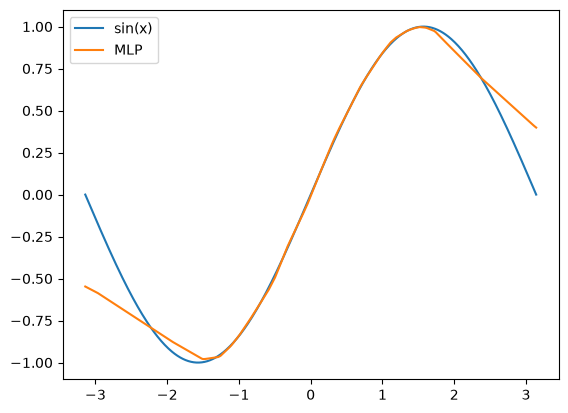

In [ ]:
# Testing phase
x_test = torch.linspace(-torch.pi,torch.pi, 500).unsqueeze(1) # inputs
with torch.no_grad(): # don't generate the operations graph of the mlp
    y_pred = model(x_test)

plt.plot(x_test, torch.sin(x_test), label="sin(x)") 
plt.plot(x_test, y_pred, label="MLP")
plt.legend()
